# Results and Model Evaluation

This notebook compares all trained models and evaluates their performance on the test set.

In [2]:
import sys
from pathlib import Path
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))



In [24]:
BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / 'models'

In [25]:
dt_model = joblib.load(MODEL_PATH / 'hr_dt_tuned.pickle')
rf_model = joblib.load(MODEL_PATH / 'hr_rf2.pickle')
logreg_model = joblib.load(MODEL_PATH / 'logreg.pickle')


## 1. Model Performance Comparison

In [26]:
def evaluate_model(model, name, X_test, y_test):
   
    # Get predictions
    if hasattr(model, 'best_estimator_'):
        # For GridSearchCV objects
        y_pred = model.best_estimator_.predict(X_test)
        y_pred_proba = model.best_estimator_.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }
    
    return metrics, y_pred, y_pred_proba



In [30]:
results = []
predictions = {}
models = [
        (dt_model, 'Decision Tree'), 
        (rf_model, 'Random Forest'), 
        # (logreg_model, 'Logistic Regression')
        ]

for model, name in models:
    if model is not None:
        metrics, y_pred, y_pred_proba = evaluate_model(model, name, X_test, y_test)
        results.append(metrics)
        predictions[name] = {'pred': y_pred, 'proba': y_pred_proba}

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Decision Tree,0.943963,0.785467,0.911647,0.843866,0.952284
1,Random Forest,0.962642,0.871154,0.909639,0.889980,0.969375


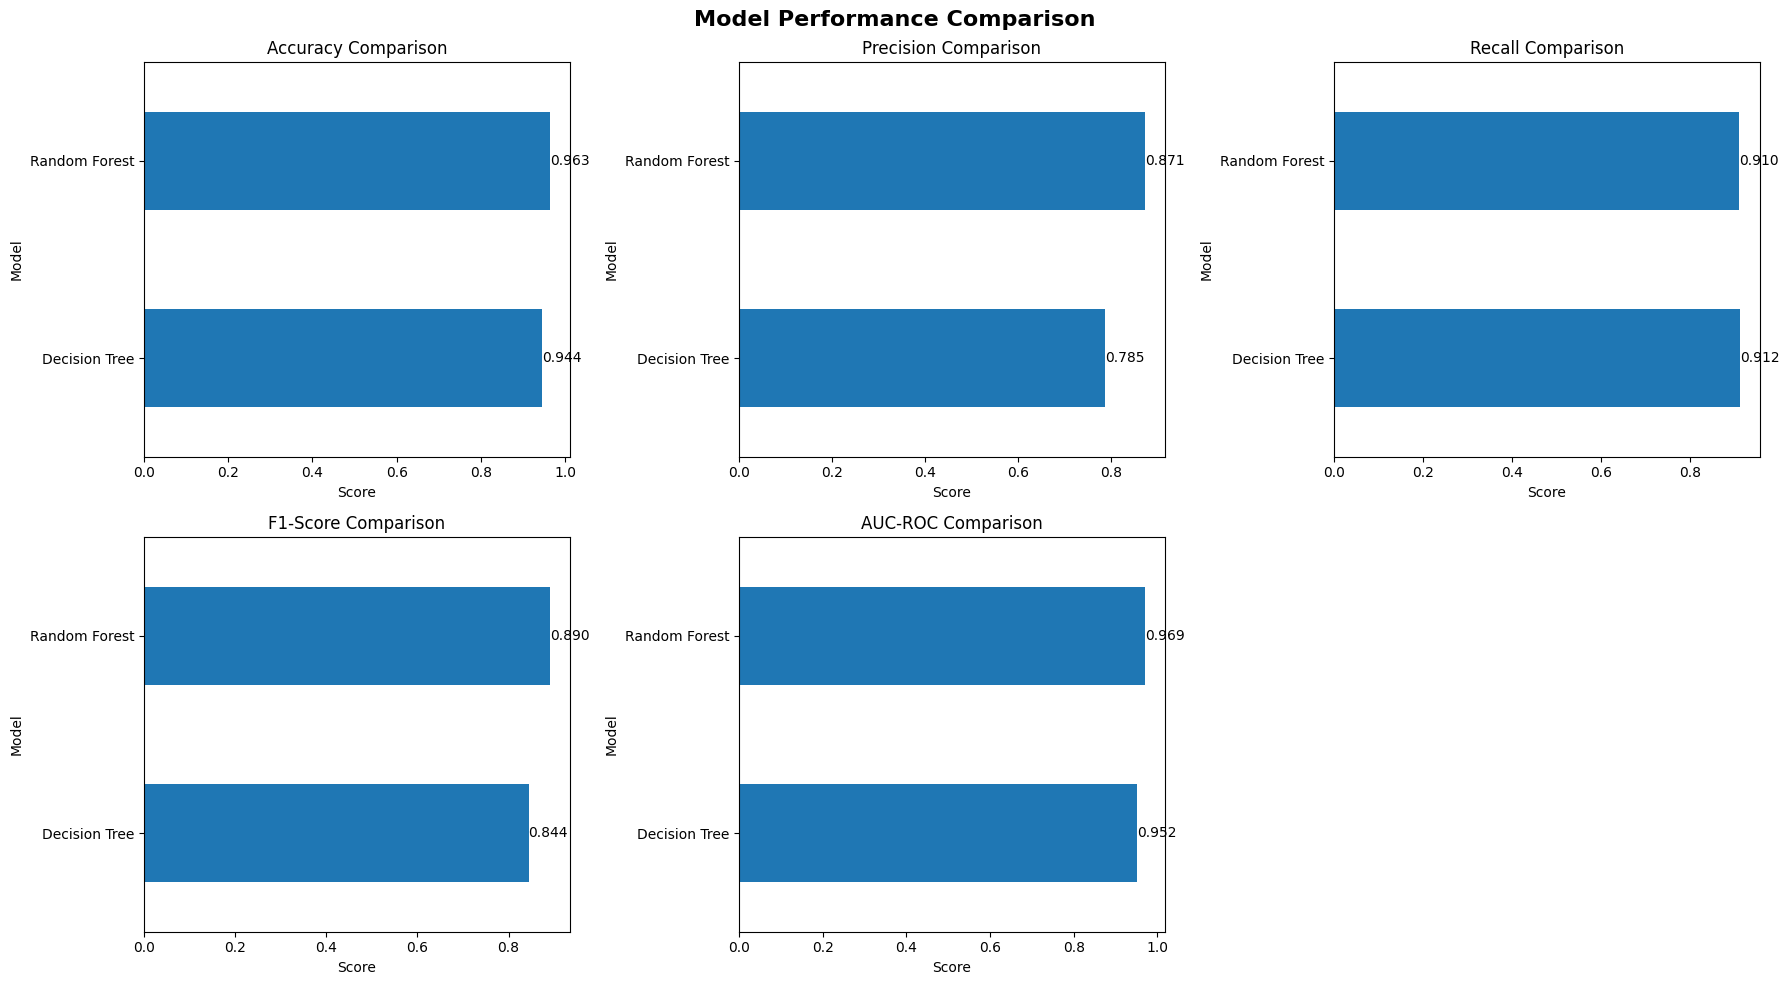

In [31]:
# Visualize metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_cols):
    ax = axes_flat[idx]
    results_df.plot(x='Model', y=metric, kind='barh', ax=ax, legend=False)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel('Score')
    ax.set_ylabel('Model')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

fig.delaxes(axes_flat[-1])
plt.tight_layout()
plt.show()

## 2. Confusion Matrices

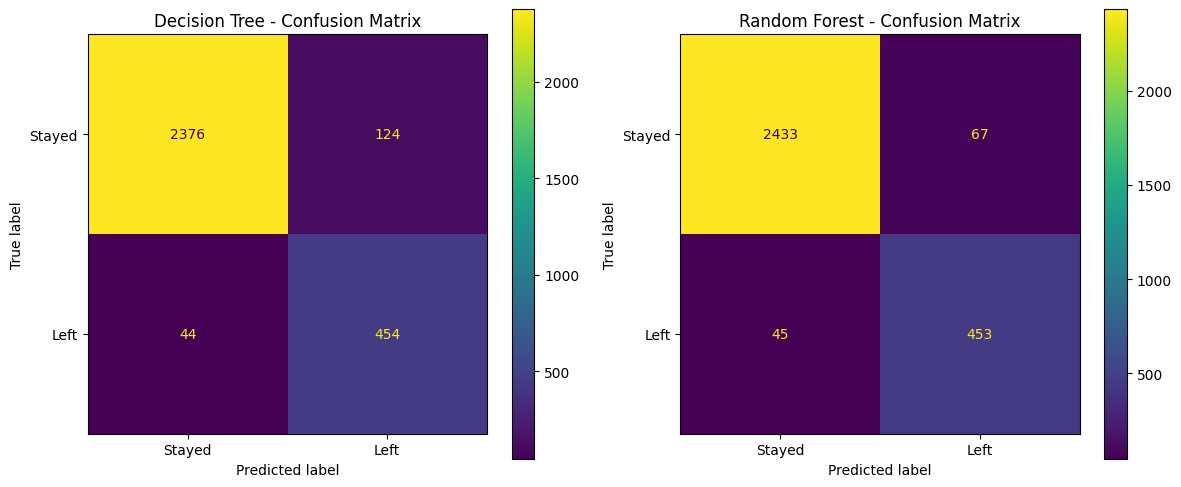

In [32]:
fig, axes = plt.subplots(1, len(predictions), figsize=(6*len(predictions), 5))
if len(predictions) == 1:
    axes = [axes]

for idx, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds['pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=['Stayed', 'Left'])
    disp.plot(ax=axes[idx], values_format='d')
    axes[idx].set_title(f'{name} - Confusion Matrix')

plt.tight_layout()
plt.show()

## 3. ROC Curves Comparison

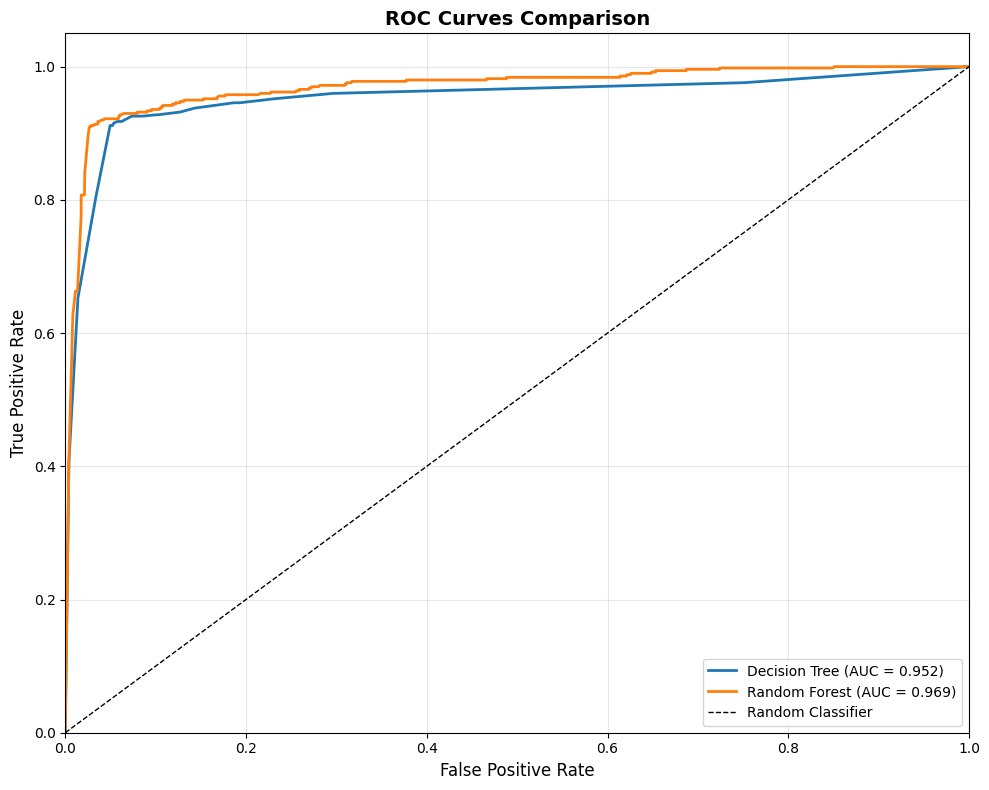

In [33]:
plt.figure(figsize=(10, 8))

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds['proba'])
    auc_score = roc_auc_score(y_test, preds['proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Precision-Recall Curves

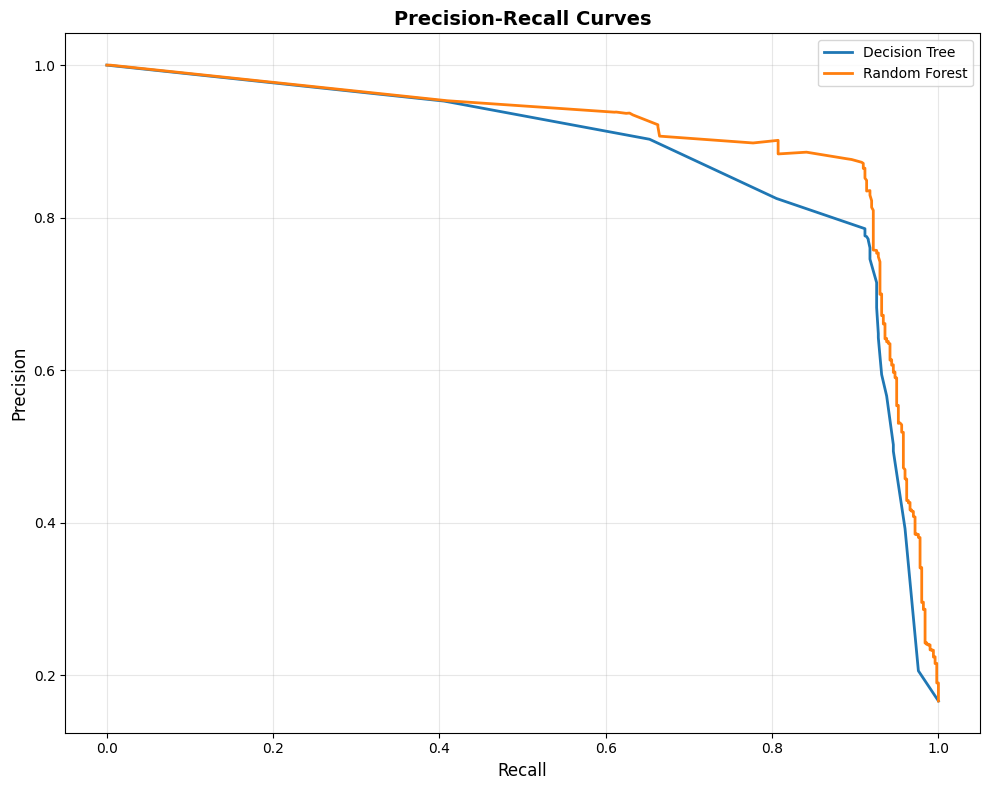

In [34]:
plt.figure(figsize=(10, 8))

for name, preds in predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, preds['proba'])
    plt.plot(recall, precision, label=f'{name}', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Predicted vs Actual Analysis

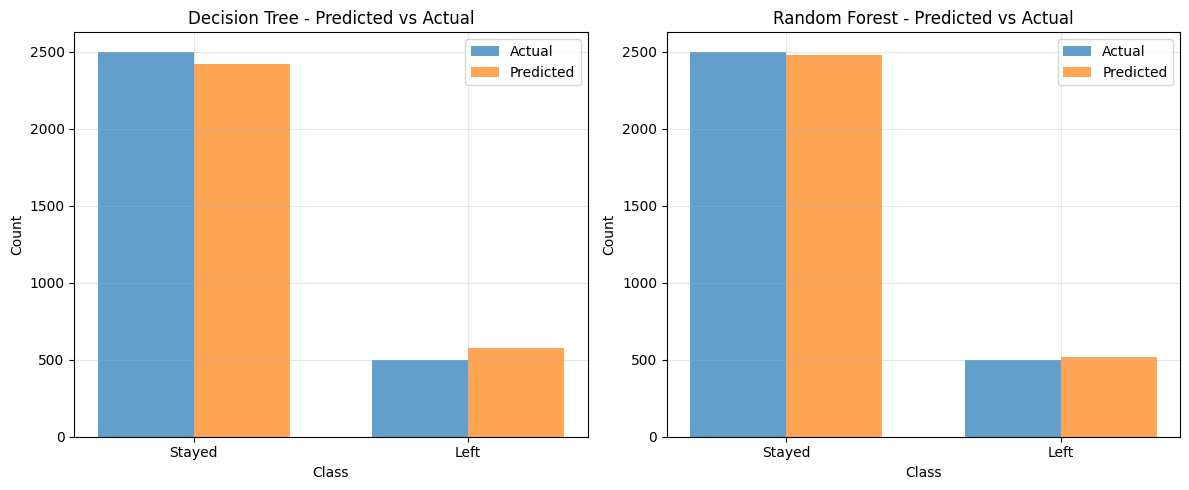

In [35]:
fig, axes = plt.subplots(1, len(predictions), figsize=(6*len(predictions), 5))
if len(predictions) == 1:
    axes = [axes]

for idx, (name, preds) in enumerate(predictions.items()):
    pred_counts = pd.Series(preds['pred']).value_counts().sort_index()
    actual_counts = pd.Series(y_test).value_counts().sort_index()
    
    x = np.arange(len(actual_counts))
    width = 0.35
    
    axes[idx].bar(x - width/2, actual_counts.values, width, label='Actual', alpha=0.7)
    axes[idx].bar(x + width/2, pred_counts.values, width, label='Predicted', alpha=0.7)
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'{name} - Predicted vs Actual')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['Stayed', 'Left'])
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Residual Analysis (Predicted Probability vs Residual)

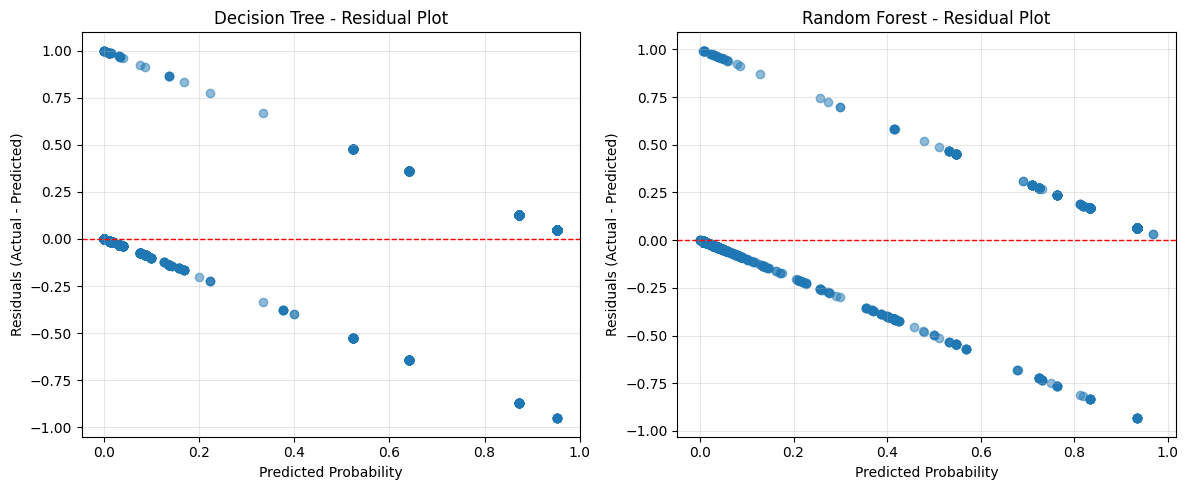

In [36]:
fig, axes = plt.subplots(1, len(predictions), figsize=(6*len(predictions), 5))
if len(predictions) == 1:
    axes = [axes]

for idx, (name, preds) in enumerate(predictions.items()):
    residuals = y_test.values - preds['proba']
    
    axes[idx].scatter(preds['proba'], residuals, alpha=0.5)
    axes[idx].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[idx].set_xlabel('Predicted Probability')
    axes[idx].set_ylabel('Residuals (Actual - Predicted)')
    axes[idx].set_title(f'{name} - Residual Plot')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Ranking Summary

In [37]:
print("MODEL PERFORMANCE SUMMARY")

results_sorted = results_df.sort_values('AUC-ROC', ascending=False)

print("\nOverall Ranking (by AUC-ROC):")
for idx, row in results_sorted.iterrows():
    print(f"{idx+1}. {row['Model']}")
    print(f"   AUC-ROC: {row['AUC-ROC']:.4f}")
    print(f"   Accuracy: {row['Accuracy']:.4f}")
    print(f"   F1-Score: {row['F1-Score']:.4f}\n")

print("\nDetailed Metrics Table:")
print(results_df.round(4).to_string(index=False))

MODEL PERFORMANCE SUMMARY

Overall Ranking (by AUC-ROC):
2. Random Forest
   AUC-ROC: 0.9694
   Accuracy: 0.9626
   F1-Score: 0.8900

1. Decision Tree
   AUC-ROC: 0.9523
   Accuracy: 0.9440
   F1-Score: 0.8439


Detailed Metrics Table:
        Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Decision Tree    0.9440     0.7855  0.9116    0.8439   0.9523
Random Forest    0.9626     0.8712  0.9096    0.8900   0.9694


### Interpreting Model Performance & Results (Focusing on Best Model)



**Best Model:** The Random Forest model demonstrated the strongest performance.

**Key Metrics:**

- AUC: 93.8%  - This indicates an excellent ability to distinguish between employees who will leave and those who will stay.

- Precision: 87.0%  - This shows when the model predicts an employee will leave, it's correct around 87% (or more) of the time.

- Recall: 90.36%  - The model successfully identifies about 90% (or more) of employees who actually end up leaving.

- F1-Score: 88.7%  - This shows a strong balance between precision and recall.

- Accuracy: 96.2% .Overall, the model makes correct predictions (leave/stay) for a very high percentage of employees.